In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
#Setting project paths
cwd = Path.cwd().resolve()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd

DATA_PATH = BASE_DIR / "data" / "processed" / "modeling_dataset.csv"

OUTPUT_DIR = BASE_DIR / "outputs" / "xgboost_modeling"
FIGURE_DIR = BASE_DIR / "outputs" / "final_figures" / "xgboost_modeling"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data path:", DATA_PATH)

Base directory: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis
Data path: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\modeling_dataset.csv


In [3]:
#Loading modelling dataset
fleet_df = pd.read_csv(DATA_PATH)
fleet_df["date"] = pd.to_datetime(fleet_df["date"])
fleet_df = fleet_df.sort_values(["blower_id", "date"]).copy()

fleet_df.head()

,date,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph,blower_id,site_id,operational_class,max_op_ambient_temp_c,...,health_score,maintenance_event_triggered,failure_event,RUL_days,maintenance_due_90d,previous_maintenance_event,maintenance_cycle,days_since_maintenance,cycle_start_cumulative_hours,hours_since_maintenance
0,2025-01-01,35.777778,23.555556,29.333333,63.9,17.2,ZG150_B001,Site_01,High Duty,48.9,...,99.262303,0,0,165.103543,0,0,0,0,22.457076,0.000000
1,2025-01-02,31.777778,20.722222,26.055556,79.5,15.0,ZG150_B001,Site_01,High Duty,48.9,...,98.703011,0,0,164.173270,0,0,0,1,22.457076,20.440024
2,2025-01-03,31.611111,22.222222,26.611111,78.3,13.9,ZG150_B001,Site_01,High Duty,48.9,...,98.176655,0,0,163.297779,0,0,0,2,22.457076,43.565701
3,2025-01-04,32.722222,23.722222,28.000000,71.4,12.9,ZG150_B001,Site_01,High Duty,48.9,...,97.606606,0,0,162.349612,0,0,0,3,22.457076,66.976548
4,2025-01-05,34.111111,22.500000,29.388889,66.3,19.8,ZG150_B001,Site_01,High Duty,48.9,...,96.939732,0,0,161.240397,0,0,0,4,22.457076,86.976548


In [4]:
print(fleet_df.shape)
print(fleet_df.info())

fleet_df.describe()

(4380, 34)
<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          4380 non-null   datetime64[us]
 1   amb_temp_max_c                4380 non-null   float64       
 2   amb_temp_min_c                4380 non-null   float64       
 3   amb_temp_avg_c                4380 non-null   float64       
 4   humidity                      4380 non-null   float64       
 5   wind_gust_kph                 4380 non-null   float64       
 6   blower_id                     4380 non-null   str           
 7   site_id                       4380 non-null   str           
 8   operational_class             4380 non-null   str           
 9   max_op_ambient_temp_c         4380 non-null   float64       
 10  failure_threshold             4380 non-null   float64       
 11  max_op_rpm                    

,date,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph,max_op_ambient_temp_c,failure_threshold,max_op_rpm,daily_op_hours,...,health_score,maintenance_event_triggered,failure_event,RUL_days,maintenance_due_90d,previous_maintenance_event,maintenance_cycle,days_since_maintenance,cycle_start_cumulative_hours,hours_since_maintenance
count,4380,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4.380000e+03,4380.0,4380.0,4380.000000,...,4380.000000,4380.000000,4380.0,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000
mean,2025-07-02 00:00:00,28.866819,16.471081,22.343836,65.441918,18.764658,4.890000e+01,1.0,3000.0,16.262854,...,67.126650,0.008447,0.0,129.184593,0.753196,0.008447,1.213242,49.711872,2184.809010,793.999659
min,2025-01-01 00:00:00,18.666667,3.833333,12.500000,23.000000,8.100000,4.890000e+01,1.0,3000.0,6.000000,...,30.188930,0.000000,0.0,47.878817,0.000000,0.000000,0.000000,0.000000,8.538562,0.000000
25%,2025-04-02 00:00:00,25.833333,13.222222,19.277778,57.100000,14.100000,4.890000e+01,1.0,3000.0,12.750000,...,54.466963,0.000000,0.0,103.366261,1.000000,0.000000,0.000000,22.750000,21.245626,337.974106
50%,2025-07-02 00:00:00,29.055556,17.277778,22.833333,67.400000,17.700000,4.890000e+01,1.0,3000.0,16.534913,...,68.507714,0.000000,0.0,130.196410,1.000000,0.000000,1.000000,47.000000,2085.637716,712.321827
75%,2025-10-01 00:00:00,31.666667,20.055556,24.888889,74.600000,22.800000,4.890000e+01,1.0,3000.0,20.993924,...,80.225315,0.000000,0.0,154.799169,1.000000,0.000000,2.000000,75.000000,3513.539828,1170.540989
max,2025-12-31 00:00:00,41.055556,25.222222,30.388889,95.500000,37.800000,4.890000e+01,1.0,3000.0,24.000000,...,99.639415,1.000000,0.0,212.804780,1.000000,1.000000,4.000000,135.000000,7442.737299,2504.997492
std,NaN,4.112604,4.312320,3.605888,13.972629,5.735775,1.421248e-14,0.0,0.0,5.131641,...,15.924478,0.091532,0.0,32.852497,0.431201,0.091532,1.051628,31.652827,1986.505867,551.269515


In [5]:
#Checking missing values
missing_values = fleet_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [6]:
# Recreating maintenance-window and maintenance-history features if missing
required_maintenance_features = [
    "maintenance_due_90d",
    "previous_maintenance_event",
    "maintenance_cycle",
    "days_since_maintenance",
    "hours_since_maintenance"
]

if not all(col in fleet_df.columns for col in required_maintenance_features):

    print("Some maintenance features are missing. Recreating them...")

    fleet_df = fleet_df.sort_values(["blower_id", "date"]).copy()

    # Future maintenance due within 90 days
    fleet_df["maintenance_due_90d"] = (
        fleet_df.groupby("blower_id")["maintenance_event"]
        .transform(lambda x: x[::-1].rolling(window=90, min_periods=1).max()[::-1])
        .astype(int)
    )

    # Previous day maintenance event
    fleet_df["previous_maintenance_event"] = (
        fleet_df.groupby("blower_id")["maintenance_event"]
        .shift(1)
        .fillna(0)
    )

    # Maintenance cycle counter
    fleet_df["maintenance_cycle"] = (
        fleet_df.groupby("blower_id")["previous_maintenance_event"]
        .cumsum()
    )

    # Days since maintenance
    fleet_df["days_since_maintenance"] = (
        fleet_df.groupby(["blower_id", "maintenance_cycle"])
        .cumcount()
    )

    # Hours since maintenance
    fleet_df["cycle_start_cumulative_hours"] = (
        fleet_df.groupby(["blower_id", "maintenance_cycle"])["cumulative_op_hours"]
        .transform("first")
    )

    fleet_df["hours_since_maintenance"] = (
        fleet_df["cumulative_op_hours"] - fleet_df["cycle_start_cumulative_hours"]
    )

else:
    print("All required maintenance features are already available.")

All required maintenance features are already available.


In [7]:
#Defining model features and target
target = "RUL_days"

feature_sets = {
    "Option_A_Full_Model": [
        "daily_op_hours",
        "cumulative_op_hours",
        "days_since_maintenance",
        "hours_since_maintenance",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
        "operational_class",
    ],

    "Option_B_Reduced_With_Duty_Class": [
        "daily_op_hours",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
        "operational_class",
    ],

    "Option_C_Condition_Only": [
        "daily_op_hours",
        "daily_load_percent",
        "humidity",
        "wind_gust_kph",
        "dust_index",
        "pressure_diff_psi",
        "casing_temperature_c",
        "vibration_mm_s",
    ]
}

for option_name, features in feature_sets.items():
    print("\n" + "=" * 70)
    print(option_name)
    print("=" * 70)
    for f in features:
        print("-", f)




Option_A_Full_Model
- daily_op_hours
- cumulative_op_hours
- days_since_maintenance
- hours_since_maintenance
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s
- operational_class

Option_B_Reduced_With_Duty_Class
- daily_op_hours
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s
- operational_class

Option_C_Condition_Only
- daily_op_hours
- daily_load_percent
- humidity
- wind_gust_kph
- dust_index
- pressure_diff_psi
- casing_temperature_c
- vibration_mm_s


In [8]:
# Time-based train-test split. Same split used in Random Forest
split_date = pd.Timestamp("2025-10-01")
print("Split date:", split_date)

Split date: 2025-10-01 00:00:00


In [9]:
# Function to train and evaluate one XGBoost model
def train_xgboost_option(option_name, model_features, fleet_df, target, split_date):
    print("\n" + "=" * 80)
    print(f"Training {option_name}")
    print("=" * 80)

    model_df = fleet_df.dropna(subset=model_features + [target]).copy()

    X = model_df[model_features].copy()
    y = model_df[target].copy()

    if "operational_class" in X.columns:
        X = pd.get_dummies(
            X,
            columns=["operational_class"],
            drop_first=False
        )

    train_mask = model_df["date"] < split_date
    test_mask = model_df["date"] >= split_date

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    print("Training records:", X_train.shape[0])
    print("Testing records:", X_test.shape[0])
    print("Number of features:", X_train.shape[1])

    xgb_regressor = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_regressor.fit(X_train, y_train)

    y_pred = xgb_regressor.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nResults")
    print("-" * 40)
    print(f"MAE:  {mae:.2f} days")
    print(f"RMSE: {rmse:.2f} days")
    print(f"R²:   {r2:.4f}")

    metrics_df = pd.DataFrame([{
        "option": option_name,
        "model": "XGBoost Regressor",
        "target": target,
        "number_of_features": X_train.shape[1],
        "train_start": model_df.loc[train_mask, "date"].min(),
        "train_end": model_df.loc[train_mask, "date"].max(),
        "test_start": model_df.loc[test_mask, "date"].min(),
        "test_end": model_df.loc[test_mask, "date"].max(),
        "mae_days": mae,
        "rmse_days": rmse,
        "r2_score": r2
    }])

    test_predictions = model_df.loc[test_mask, [
        "date",
        "blower_id",
        "site_id",
        "operational_class",
        "RUL_days",
        "degradation_index",
        "health_score",
        "maintenance_event",
        "maintenance_due_90d"
    ]].copy()

    pred_col = f"{option_name}_predicted_RUL_days"
    error_col = f"{option_name}_absolute_error_days"
    residual_col = f"{option_name}_residual_days"

    test_predictions[pred_col] = y_pred
    test_predictions[error_col] = (
        test_predictions["RUL_days"] - test_predictions[pred_col]
    ).abs()

    test_predictions[residual_col] = (
        test_predictions["RUL_days"] - test_predictions[pred_col]
    )

    test_predictions[f"{option_name}_maintenance_due_90d_pred"] = (
        test_predictions[pred_col] <= 90
    ).astype(int)

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgb_regressor.feature_importances_
    }).sort_values(by="importance", ascending=False)

    full_predictions = xgb_regressor.predict(X)
    full_predictions = np.clip(full_predictions, 0, None)

    full_prediction_df = model_df.copy()
    full_prediction_df[pred_col] = full_predictions


    full_prediction_df[f"{option_name}_maintenance_due_90d_pred"] = (
        full_prediction_df[pred_col] <= 90
    ).astype(int)

    full_prediction_df["data_split"] = np.where(
        full_prediction_df["date"] < split_date,
        "train",
        "test"
    )

    return {
        "option_name": option_name,
        "model": xgb_regressor,
        "metrics": metrics_df,
        "test_predictions": test_predictions,
        "feature_importance": importance_df,
        "full_predictions": full_prediction_df,
        "pred_col": pred_col,
        "residual_col": residual_col,
        "X_train_columns": X_train.columns.tolist()
    }

In [10]:
# Training all 3 XGBoost Regressor
xgb_results = {}

for option_name, features in feature_sets.items():
    xgb_results[option_name] = train_xgboost_option(
        option_name=option_name,
        model_features=features,
        fleet_df=fleet_df,
        target=target,
        split_date=split_date
    )


Training Option_A_Full_Model
Training records: 3276
Testing records: 1104
Number of features: 14

Results
----------------------------------------
MAE:  12.36 days
RMSE: 16.71 days
R²:   0.6926

Training Option_B_Reduced_With_Duty_Class
Training records: 3276
Testing records: 1104
Number of features: 11

Results
----------------------------------------
MAE:  28.15 days
RMSE: 34.84 days
R²:   -0.3372

Training Option_C_Condition_Only
Training records: 3276
Testing records: 1104
Number of features: 8

Results
----------------------------------------
MAE:  28.34 days
RMSE: 35.11 days
R²:   -0.3580


In [11]:
# Combining and saving metrics comparison

metrics_comparison = pd.concat(
    [result["metrics"] for result in xgb_results.values()],
    ignore_index=True
).sort_values(by="rmse_days")

metrics_comparison_path = OUTPUT_DIR / "xgboost_three_option_metrics_comparison.csv"

metrics_comparison.to_csv(
    metrics_comparison_path,
    index=False
)

metrics_comparison

,option,model,target,number_of_features,train_start,train_end,test_start,test_end,mae_days,rmse_days,r2_score
0,Option_A_Full_Model,XGBoost Regressor,RUL_days,14,2025-01-01,2025-09-30,2025-10-01,2025-12-31,12.362651,16.707719,0.692551
1,Option_B_Reduced_With_Duty_Class,XGBoost Regressor,RUL_days,11,2025-01-01,2025-09-30,2025-10-01,2025-12-31,28.153909,34.844332,-0.337218
2,Option_C_Condition_Only,XGBoost Regressor,RUL_days,8,2025-01-01,2025-09-30,2025-10-01,2025-12-31,28.339596,35.114550,-0.358039


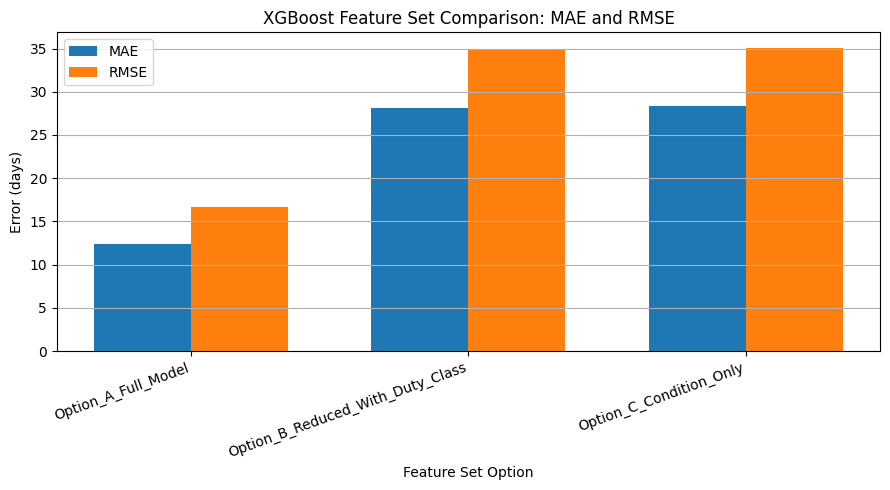

In [12]:
# Plotting metrics comparison: MAE and RMSE
plot_metrics = metrics_comparison.copy()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_metrics))
width = 0.35

ax.bar(
    x - width / 2,
    plot_metrics["mae_days"],
    width,
    label="MAE"
)

ax.bar(
    x + width / 2,
    plot_metrics["rmse_days"],
    width,
    label="RMSE"
)

ax.set_title("XGBoost Feature Set Comparison: MAE and RMSE")
ax.set_xlabel("Feature Set Option")
ax.set_ylabel("Error (days)")
ax.set_xticks(x)
ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")
ax.legend()
ax.grid(True, axis="y")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "xgboost_three_option_mae_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15560\2179613661.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")


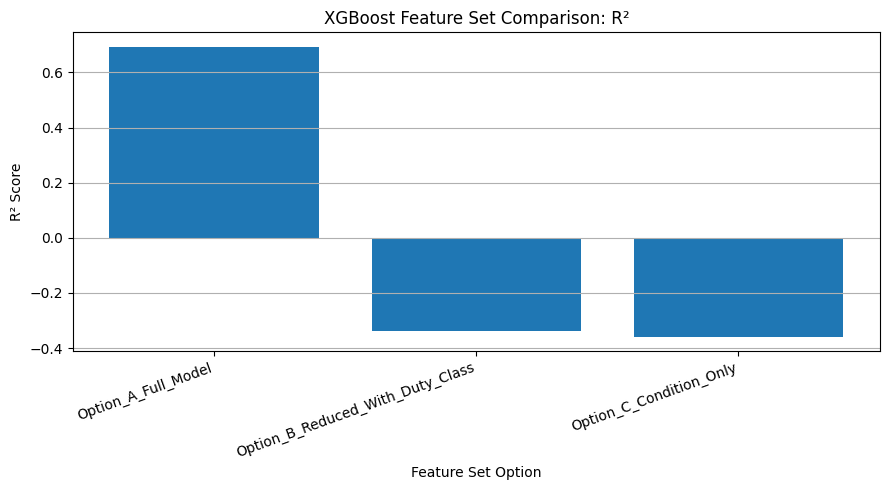

In [13]:
# Plotting metrics comparison: R²

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_metrics["option"],
    plot_metrics["r2_score"]
)

ax.set_title("XGBoost Feature Set Comparison: R²")
ax.set_xlabel("Feature Set Option")
ax.set_ylabel("R² Score")
ax.set_xticklabels(plot_metrics["option"], rotation=20, ha="right")
ax.grid(True, axis="y")

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "xgboost_three_option_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Saving outputs and plots for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    # Saving model
    model_path = OUTPUT_DIR / f"{safe_name}_xgboost_rul_model.json"
    result["model"].save_model(str(model_path))

    # Saving test predictions
    test_predictions_path = OUTPUT_DIR / f"{safe_name}_test_predictions.csv"
    result["test_predictions"].to_csv(test_predictions_path, index=False)

    # Saving feature importance
    importance_path = OUTPUT_DIR / f"{safe_name}_feature_importance.csv"
    result["feature_importance"].to_csv(importance_path, index=False)

    # Saving full predictions
    full_predictions_path = PROCESSED_DIR / f"{safe_name}_modeling_dataset_with_predictions.csv"
    result["full_predictions"].to_csv(full_predictions_path, index=False)

    # Saving test-only policy predictions
    test_policy_path = PROCESSED_DIR / f"{safe_name}_test_policy_predictions.csv"
    result["test_predictions"].to_csv(test_policy_path, index=False)

    print(f"\nSaved outputs for {option_name}")
    print("- Model:", model_path)
    print("- Test predictions:", test_predictions_path)
    print("- Feature importance:", importance_path)
    print("- Full predictions:", full_predictions_path)
    print("- Test-only policy predictions:", test_policy_path)


Saved outputs for Option_A_Full_Model
- Model: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling\option_a_full_model_xgboost_rul_model.json
- Test predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling\option_a_full_model_test_predictions.csv
- Feature importance: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling\option_a_full_model_feature_importance.csv
- Full predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\option_a_full_model_modeling_dataset_with_predictions.csv
- Test-only policy predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\option_a_full_model_test_policy_predictions.csv

Saved outputs for Option_B_Reduced_With_Duty_Class
- Model: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling\option_b_reduced_wit

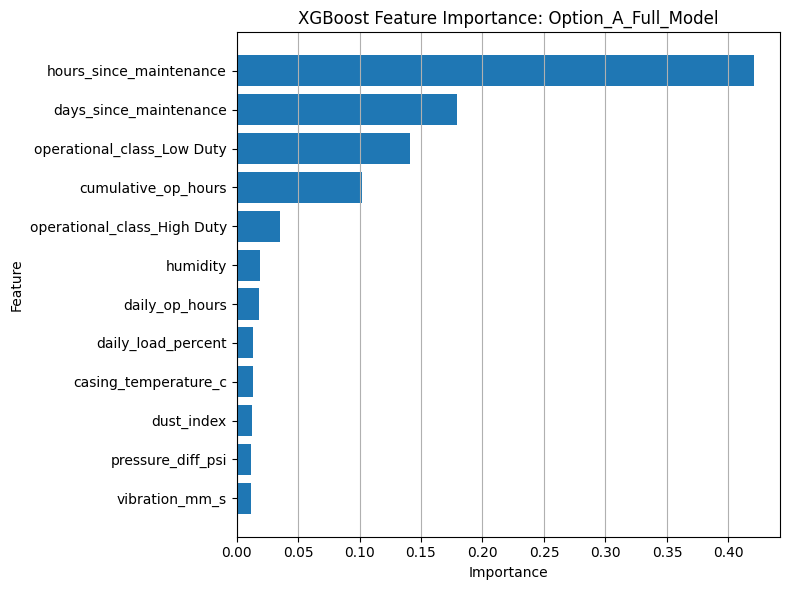

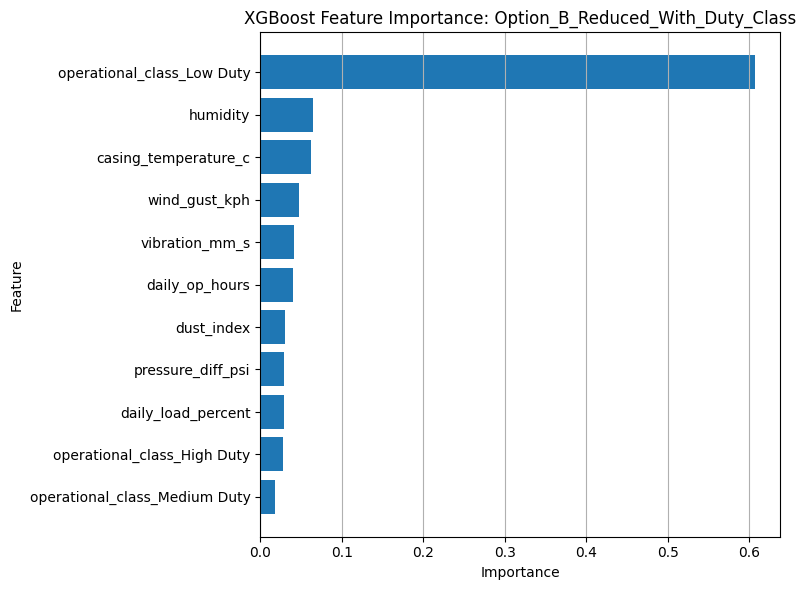

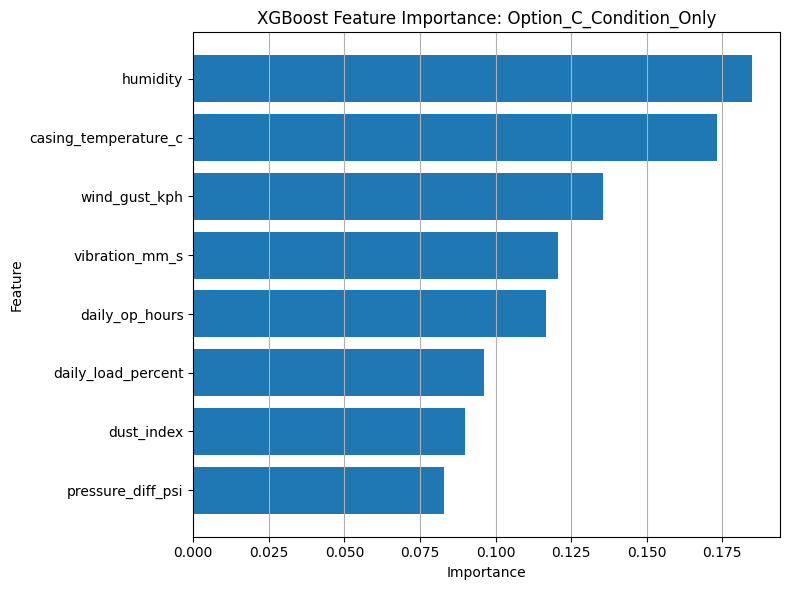

In [15]:
# Plotting feature importance for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    importance_df = result["feature_importance"]

    top_n = min(12, len(importance_df))

    plot_df = importance_df.sort_values(
        by="importance",
        ascending=True
    ).tail(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    ax.set_title(f"XGBoost Feature Importance: {option_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.grid(True, axis="x")

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

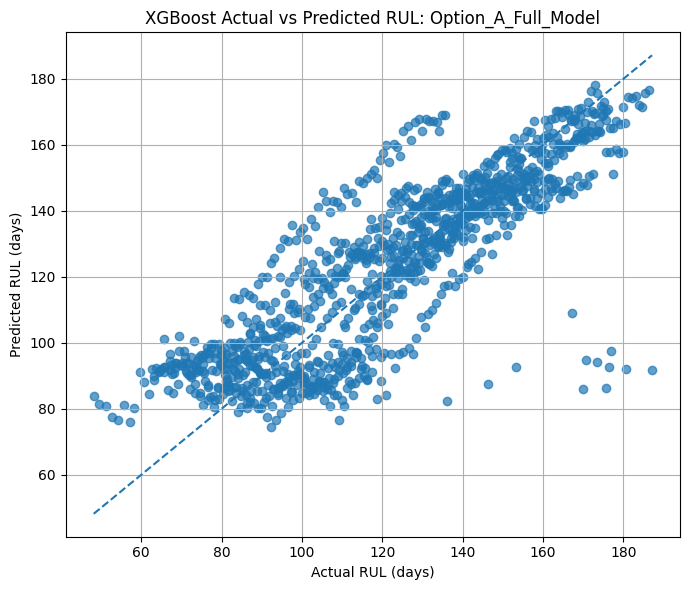

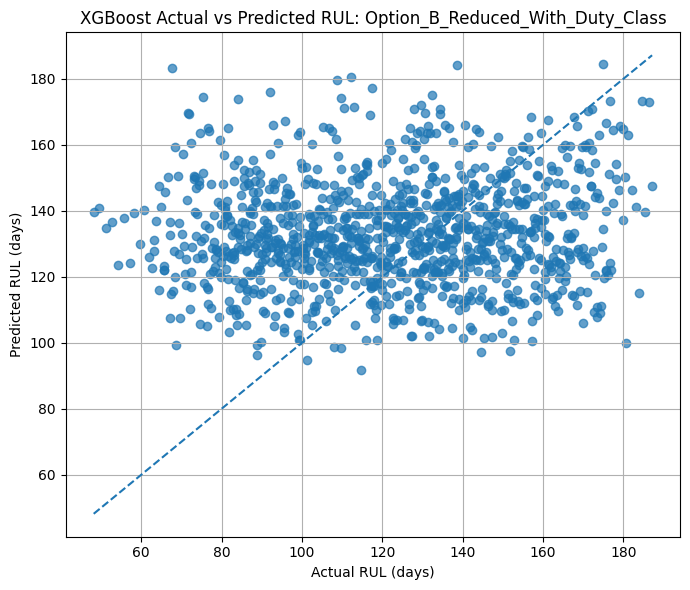

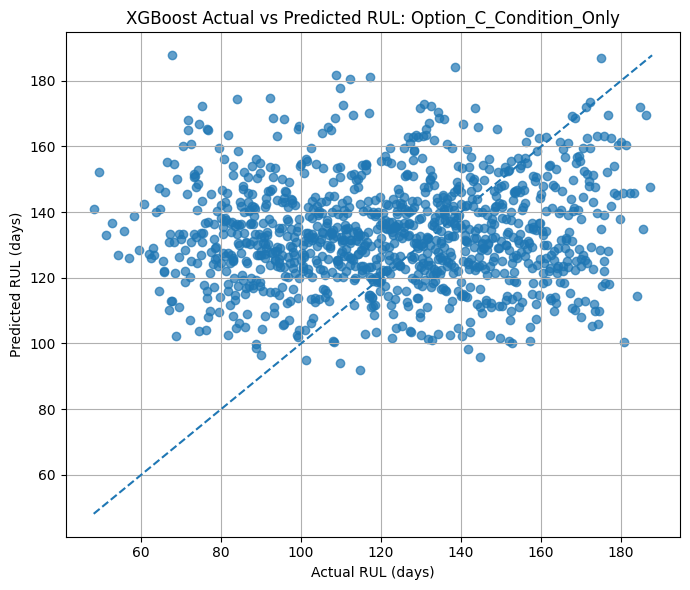

In [16]:
# Plotting actual vs predicted RUL scatter for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(
        test_predictions["RUL_days"],
        test_predictions[pred_col],
        alpha=0.7
    )

    min_value = min(
        test_predictions["RUL_days"].min(),
        test_predictions[pred_col].min()
    )

    max_value = max(
        test_predictions["RUL_days"].max(),
        test_predictions[pred_col].max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_title(f"XGBoost Actual vs Predicted RUL: {option_name}")
    ax.set_xlabel("Actual RUL (days)")
    ax.set_ylabel("Predicted RUL (days)")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

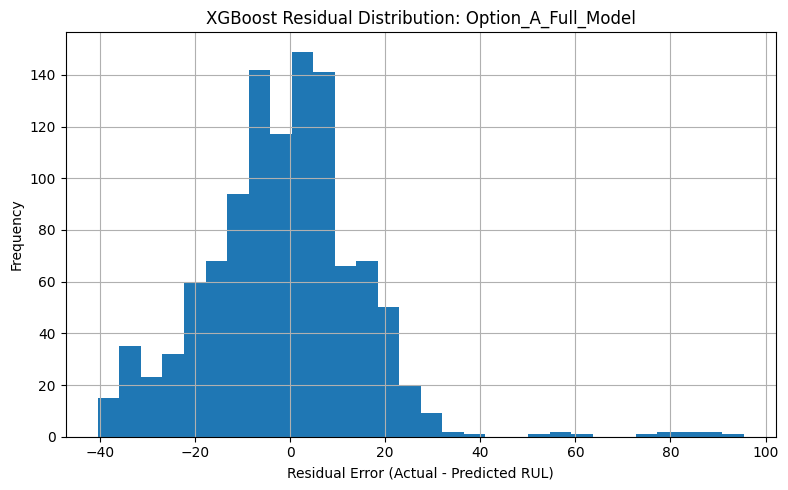

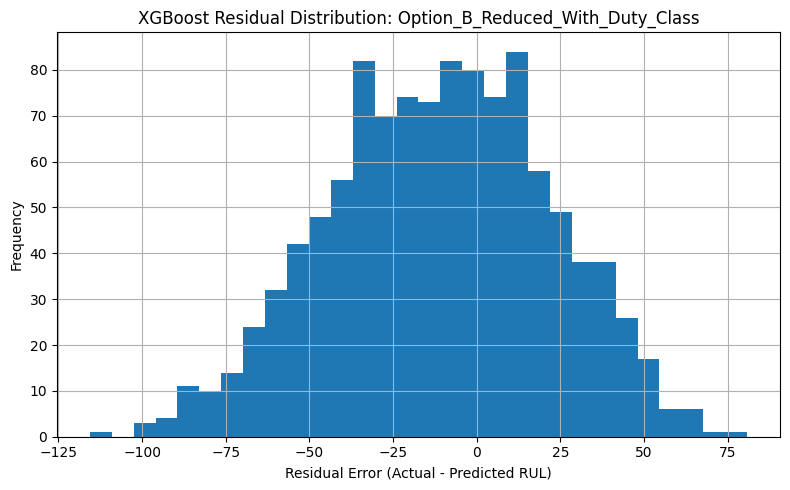

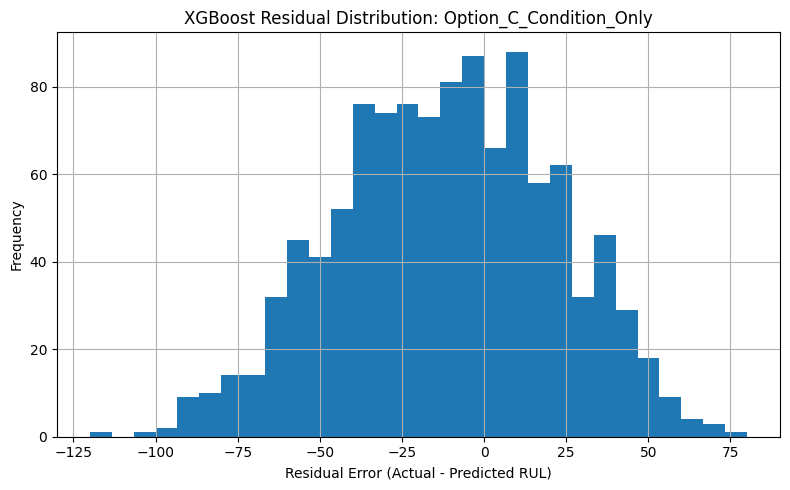

In [17]:
# Plotting residual distribution for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    residual_col = result["residual_col"]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        test_predictions[residual_col],
        bins=30
    )

    ax.set_title(f"XGBoost Residual Distribution: {option_name}")
    ax.set_xlabel("Residual Error (Actual - Predicted RUL)")
    ax.set_ylabel("Frequency")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_residual_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

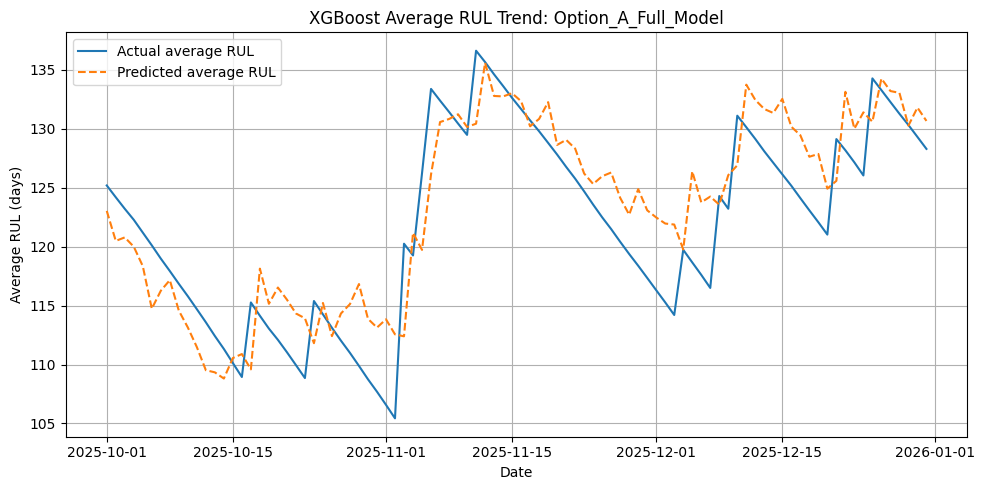

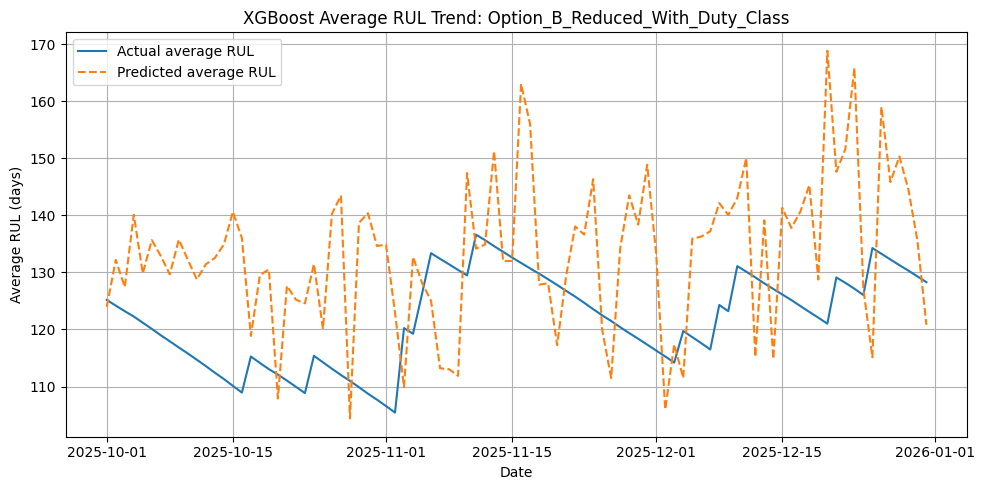

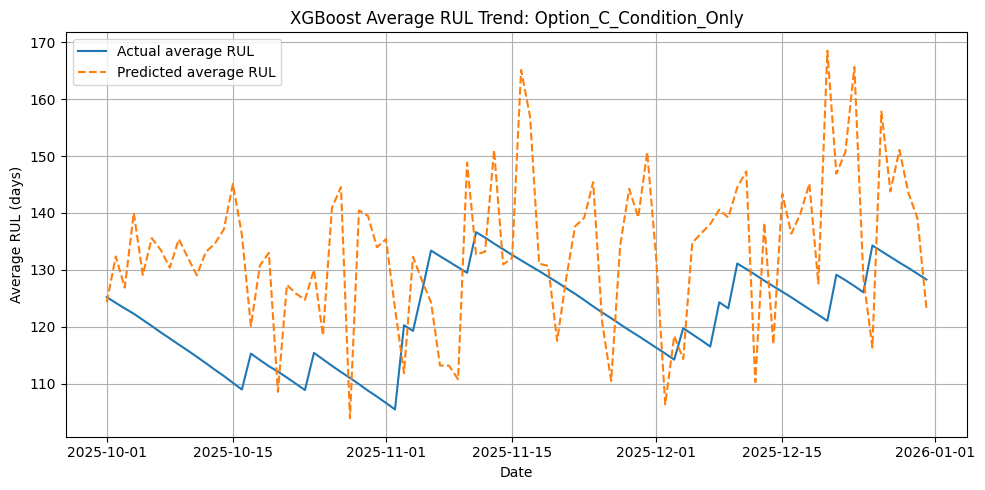

In [18]:
# Fleet-average actual vs predicted RUL trend for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    fleet_rul_trend = (
        test_predictions
        .groupby("date")[["RUL_days", pred_col]]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        fleet_rul_trend["date"],
        fleet_rul_trend["RUL_days"],
        label="Actual average RUL"
    )

    ax.plot(
        fleet_rul_trend["date"],
        fleet_rul_trend[pred_col],
        linestyle="--",
        label="Predicted average RUL"
    )

    ax.set_title(f"XGBoost Average RUL Trend: {option_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Average RUL (days)")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_average_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

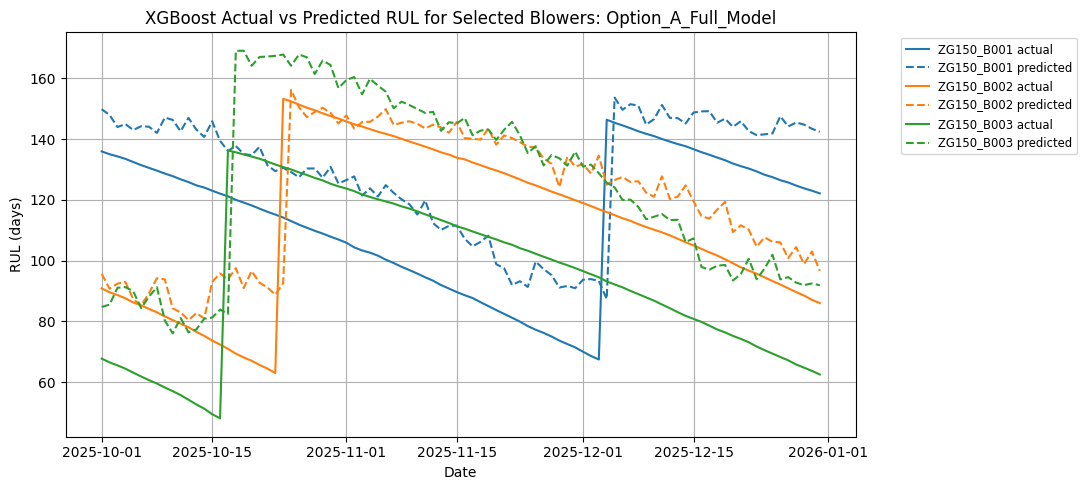

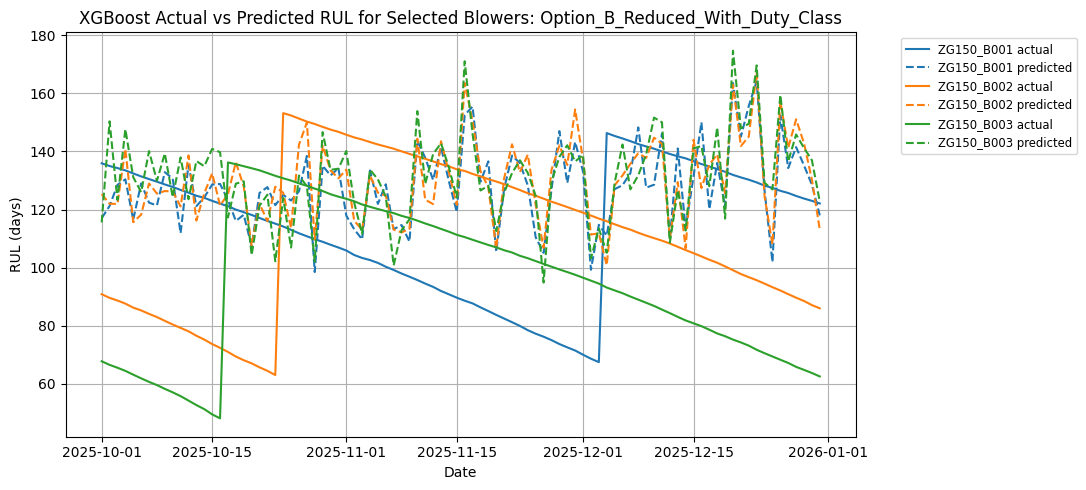

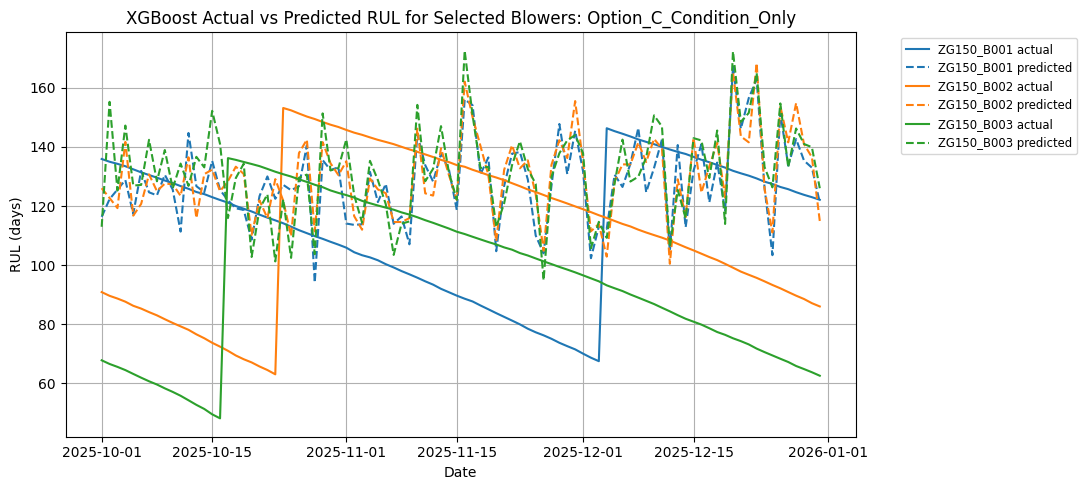

In [19]:
# Selected blower actual vs predicted RUL trend for each option

for option_name, result in xgb_results.items():

    safe_name = option_name.lower()

    test_predictions = result["test_predictions"]
    pred_col = result["pred_col"]

    selected_blowers = test_predictions["blower_id"].unique()[:3]

    fig, ax = plt.subplots(figsize=(11, 5))

    colour_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, blower in enumerate(selected_blowers):
        subset = (
            test_predictions[test_predictions["blower_id"] == blower]
            .sort_values("date")
        )

        colour = colour_cycle[i % len(colour_cycle)]

        ax.plot(
            subset["date"],
            subset["RUL_days"],
            color=colour,
            linestyle="-",
            label=f"{blower} actual"
        )

        ax.plot(
            subset["date"],
            subset[pred_col],
            color=colour,
            linestyle="--",
            label=f"{blower} predicted"
        )

    ax.set_title(f"XGBoost Actual vs Predicted RUL for Selected Blowers: {option_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("RUL (days)")
    ax.legend(fontsize="small", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / f"{safe_name}_selected_blowers_actual_vs_predicted_rul.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


In [20]:
# Creating combined test-only policy prediction dataset

combined_policy_df = None

for option_name, result in xgb_results.items():

    test_df = result["test_predictions"].copy()

    keep_cols = [
        "date",
        "blower_id",
        "site_id",
        "operational_class",
        "RUL_days",
        "degradation_index",
        "health_score",
        "maintenance_event",
        "maintenance_due_90d",
        result["pred_col"],
        f"{option_name}_maintenance_due_90d_pred"
    ]

    test_df = test_df[keep_cols].copy()

    if combined_policy_df is None:
        combined_policy_df = test_df
    else:
        merge_cols = [
            "date",
            "blower_id",
            "site_id",
            "operational_class",
            "RUL_days",
            "degradation_index",
            "health_score",
            "maintenance_event",
            "maintenance_due_90d"
        ]

        combined_policy_df = combined_policy_df.merge(
            test_df,
            on=merge_cols,
            how="left"
        )

combined_policy_path = PROCESSED_DIR / "xgboost_three_option_test_policy_predictions.csv"

combined_policy_df.to_csv(
    combined_policy_path,
    index=False
)

print("Combined policy-ready test prediction dataset saved to:")
print(combined_policy_path)

combined_policy_df.head()

Combined policy-ready test prediction dataset saved to:
C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\xgboost_three_option_test_policy_predictions.csv


,date,blower_id,site_id,operational_class,RUL_days,degradation_index,health_score,maintenance_event,maintenance_due_90d,Option_A_Full_Model_predicted_RUL_days,Option_A_Full_Model_maintenance_due_90d_pred,Option_B_Reduced_With_Duty_Class_predicted_RUL_days,Option_B_Reduced_With_Duty_Class_maintenance_due_90d_pred,Option_C_Condition_Only_predicted_RUL_days,Option_C_Condition_Only_maintenance_due_90d_pred
0,2025-10-01,ZG150_B001,Site_01,High Duty,135.921858,0.182821,81.717911,0,1,149.793167,0,117.033112,0,116.340408,0
1,2025-10-02,ZG150_B001,Site_01,High Duty,134.992977,0.188405,81.159457,0,1,147.892334,0,121.237549,0,122.355103,0
2,2025-10-03,ZG150_B001,Site_01,High Duty,134.287447,0.192647,80.735283,0,1,143.926605,0,128.503830,0,125.588631,0
3,2025-10-04,ZG150_B001,Site_01,High Duty,133.479955,0.197502,80.249809,0,1,144.901657,0,130.404556,0,128.784973,0
4,2025-10-05,ZG150_B001,Site_01,High Duty,132.430452,0.203812,79.618834,0,1,142.972488,0,116.529305,0,117.313675,0


In [21]:
# Final summary
print("XGBoost three-option modelling completed.")
print("\nMetrics comparison:")
display(metrics_comparison)

print("\nSaved outputs:")
print(f"- Metrics comparison: {metrics_comparison_path}")
print(f"- Combined policy-ready test predictions: {combined_policy_path}")
print(f"- Output directory: {OUTPUT_DIR}")
print(f"- Figure directory: {FIGURE_DIR}")

XGBoost three-option modelling completed.

Metrics comparison:


,option,model,target,number_of_features,train_start,train_end,test_start,test_end,mae_days,rmse_days,r2_score
0,Option_A_Full_Model,XGBoost Regressor,RUL_days,14,2025-01-01,2025-09-30,2025-10-01,2025-12-31,12.362651,16.707719,0.692551
1,Option_B_Reduced_With_Duty_Class,XGBoost Regressor,RUL_days,11,2025-01-01,2025-09-30,2025-10-01,2025-12-31,28.153909,34.844332,-0.337218
2,Option_C_Condition_Only,XGBoost Regressor,RUL_days,8,2025-01-01,2025-09-30,2025-10-01,2025-12-31,28.339596,35.114550,-0.358039



Saved outputs:
- Metrics comparison: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling\xgboost_three_option_metrics_comparison.csv
- Combined policy-ready test predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\xgboost_three_option_test_policy_predictions.csv
- Output directory: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\xgboost_modeling
- Figure directory: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\final_figures\xgboost_modeling
